1. Artificial neuron
2. Perceptron
3. Activation functions
4. Neural network structure
5. Forward propagation
6. Loss functions
7. Backpropagation
8. Gradient descent
9. Build NN from scratch
10. Deep neural networks
11. Regularization
12. PyTorch basics
13. Build NN using PyTorch
14. CNN
15. RNN, LSTM
16. Transformers
17. Projects


1️⃣ Concept

An artificial neuron is the basic unit of a neural network.

It mimics a biological neuron:

Takes inputs (
𝑥
1
,
𝑥
2
,
…
,
𝑥
𝑛
x
1
	​

,x
2
	​

,…,x
n
	​

)

Each input has a weight (
𝑤
1
,
𝑤
2
,
…
,
𝑤
𝑛
w
1
	​

,w
2
	​

,…,w
n
	​

)

Adds a bias (
𝑏
b)

Passes the sum through an activation function (
𝑓
f) to produce an output

Mathematical representation:

𝑦
=
𝑓
(
∑
𝑖
=
1
𝑛
𝑤
𝑖
𝑥
𝑖
+
𝑏
)
y=f(
i=1
∑
n
	​

w
i
	​

x
i
	​

+b)

Where:

𝑥
𝑖
x
i
	​

 = input

𝑤
𝑖
w
i
	​

 = weight

𝑏
b = bias

𝑓
f = activation function

In [2]:
import numpy as np 

def sigmoid(Z):
    return 1/(1+np.exp(-Z))

def relu(Z):
    return np.maximum(0,Z)


In [48]:
class Neuron:
    def __init__(self,input_size):

        # np.random.seed(42)
        self.weight = np.random.randn(input_size)
        self.bias = 0

    def forward(self,inputs):

        z =np.dot(self.weight,inputs) + self.bias

        return sigmoid(z)

inputs = np.array([0.5,0.6,0.7])

input_size = 3

neuron = Neuron(input_size)

output = neuron.forward(inputs)

output

np.float64(0.6982082501416231)

In [57]:
import numpy as np

# Step activation function
def step(x):
    return 1 if x >= 0 else 0

# Perceptron class
class Perceptron:
    def __init__(self, input_size, learning_rate=0.1):
        self.weights = np.random.randn(input_size)
        self.bias = 0.0
        self.lr = learning_rate

    def predict(self, inputs):
        z = np.dot(self.weights, inputs) + self.bias
        return step(z)

    def train(self, X, y, epochs=10):
        for epoch in range(epochs):
            for xi, yi in zip(X, y):
                y_pred = self.predict(xi)
                # Perceptron update rule
                error = yi - y_pred
                self.weights += self.lr * error * xi
                self.bias += self.lr * error
            print(f"Epoch {epoch+1}: weights={self.weights}, bias={self.bias}")




In [58]:
# Training data for AND gate
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([0, 0, 0, 1])

# Create and train perceptron
perceptron = Perceptron(input_size=2)
perceptron.train(X, y, epochs=10)

# Test perceptron
for xi in X:
    print(f"Input: {xi}, Predicted: {perceptron.predict(xi)}")

Epoch 1: weights=[-0.11967189  0.35711257], bias=-0.1
Epoch 2: weights=[-0.01967189  0.35711257], bias=-0.1
Epoch 3: weights=[-0.01967189  0.25711257], bias=-0.2
Epoch 4: weights=[0.08032811 0.25711257], bias=-0.20000000000000004
Epoch 5: weights=[0.18032811 0.25711257], bias=-0.20000000000000004
Epoch 6: weights=[0.18032811 0.15711257], bias=-0.30000000000000004
Epoch 7: weights=[0.18032811 0.15711257], bias=-0.30000000000000004
Epoch 8: weights=[0.18032811 0.15711257], bias=-0.30000000000000004
Epoch 9: weights=[0.18032811 0.15711257], bias=-0.30000000000000004
Epoch 10: weights=[0.18032811 0.15711257], bias=-0.30000000000000004
Input: [0 0], Predicted: 0
Input: [0 1], Predicted: 0
Input: [1 0], Predicted: 0
Input: [1 1], Predicted: 1


In [64]:
import numpy as np 
import matplotlib.pyplot as plt 

## activation functions

def sigmoid(x):
    return 1/(1+np.exp(-x))

def tanh(x):
    return (np.exp(x) - np.exp(-x))/(np.exp(x) + np.exp(-x))

def relu(x):
    return np.maximum(0,x)

def leaky_relu(x, alpha = 0.01):
    return np.where(x > 0, x, 0.01 * x)

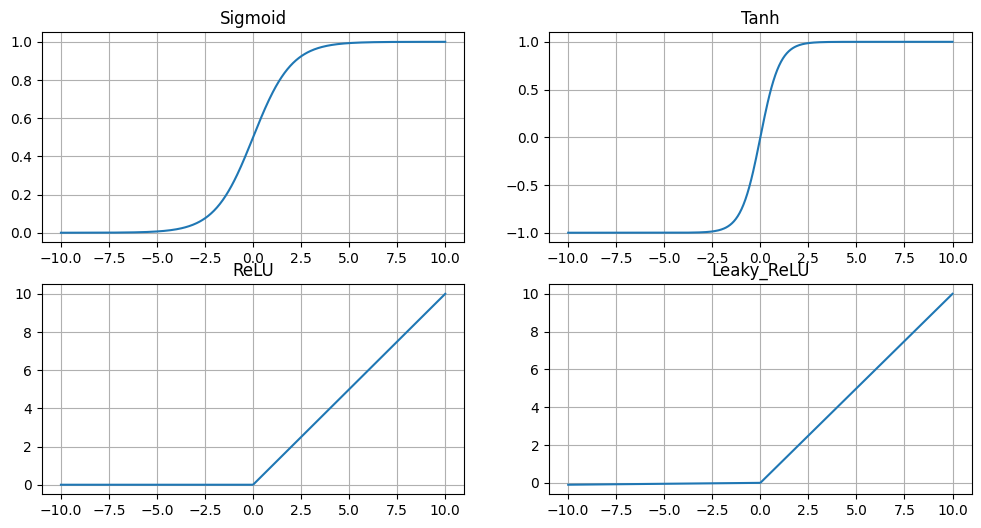

In [65]:
x = np.linspace(-10,10,400)

plt.figure(figsize=(12,6))

plt.subplot(2,2,1)
plt.plot(x, sigmoid(x))
plt.title("Sigmoid")
plt.grid(True)

plt.subplot(2,2,2)
plt.plot(x, tanh(x))
plt.title("Tanh")
plt.grid(True)

plt.subplot(2,2,3)
plt.plot(x, relu(x))
plt.title("ReLU")
plt.grid(True)

plt.subplot(2,2,4)
plt.plot(x, leaky_relu(x))
plt.title("Leaky_ReLU")
plt.grid(True)


2️⃣ Forward Pass (Single Example)

Mathematically:

Layer 1: 
ℎ
=
𝑓
(
𝑊
1
𝑥
+
𝑏
1
)
Layer 1: h=f(W
1
	​

x+b
1
	​

)
Output: 
𝑦
=
𝑓
(
𝑊
2
ℎ
+
𝑏
2
)
Output: y=f(W
2
	​

h+b
2
	​

)

Where:

𝑊
1
W
1
	​

 = weights from input to hidden

𝑏
1
b
1
	​

 = biases for hidden

𝑓
f = activation function

In [68]:
import numpy as np

# Activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# ===========================
# Simple Neural Network Class
# ===========================
class SimpleNN:
    def __init__(self, input_size, hidden_size, output_size):
        # Initialize weights randomly
        self.W1 = np.random.randn(hidden_size, input_size)  # Weights from input to hidden
        self.b1 = np.zeros((hidden_size, 1))                # Biases for hidden layer
        self.W2 = np.random.randn(output_size, hidden_size) # Weights from hidden to output
        self.b2 = np.zeros((output_size, 1))                # Biases for output layer

    def forward(self, x):
        """
        Forward pass for a single input x
        x: input vector (input_size x 1)
        """
        # Compute hidden layer activation
        self.z1 = np.dot(self.W1, x) + self.b1  # Weighted sum
        self.a1 = sigmoid(self.z1)              # Apply sigmoid activation

        # Compute output layer
        self.z2 = np.dot(self.W2, self.a1) + self.b2
        self.a2 = sigmoid(self.z2)              # Output activation

        return self.a2

In [69]:
# ===========================
# Testing the network
# ===========================
# Input vector (3 features)
x = np.array([[0.5], [0.1], [0.2]])

# Create network: 3 inputs → 4 hidden neurons → 1 output neuron
nn = SimpleNN(input_size=3, hidden_size=4, output_size=1)

# Forward pass
output = nn.forward(x)
print("Network output:", output)

Network output: [[0.62289826]]


In [70]:
## Forward Propagation

import numpy as np 

def sigmoid(x):
    return 1/(1+np.exp(-x))

def relu(x):
    return np.maximum(0,x)

In [75]:
# ===========================
# Neural Network with Forward Propagation
# ===========================
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        # Initialize weights and biases randomly
        self.W1 = np.random.randn(hidden_size, input_size) * 0.01
        self.b1 = np.zeros((hidden_size, 1))
        self.W2 = np.random.randn(output_size, hidden_size) * 0.01
        self.b2 = np.zeros((output_size, 1))

    def forward(self, x):
        """
        Forward propagation for a single input x
        """
        # --- Hidden Layer ---
        self.z1 = np.dot(self.W1, x) + self.b1  # Weighted sum
        self.a1 = relu(self.z1)                 # Activation (ReLU)

        # --- Output Layer ---
        self.z2 = np.dot(self.W2, self.a1) + self.b2  # Weighted sum
        self.a2 = sigmoid(self.z2)                     # Activation (Sigmoid for binary output)

        return self.a2

In [78]:
# ===========================
# Test the forward propagation
# ===========================
# Input features (3 features)
x = np.array([[0.5], [0.1], [0.2]])

# Create network: 3 inputs → 4 hidden → 1 output
nn = NeuralNetwork(input_size=3, hidden_size=100, output_size=1)

# Forward pass
y_pred = nn.forward(x)
print("Predicted output:", y_pred)

Predicted output: [[0.50001155]]


## Topic 6: Loss Functions

In [79]:
import numpy as np

def mse_loss(y_pred, y):
    return np.mean( (y_pred - y) ** 2 )

In [85]:
def binary_CE(y_true,y_pred):
    y_pred = np.clip(y_pred, 1e-7, 1-1e-7)

    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

In [81]:
# Example for regression
y_true_reg = np.array([2.0, 0.5, 1.0])
y_pred_reg = np.array([1.5, 0.7, 0.8])

print("MSE Loss:", mse_loss(y_true_reg, y_pred_reg))

MSE Loss: 0.10999999999999999


In [86]:
# Example for binary classification
y_true_bin = np.array([1, 0, 1, 1])
y_pred_bin = np.array([0.9, 0.2, 0.8, 0.6])

print("Binary Cross-Entropy Loss:", binary_CE(y_true_bin, y_pred_bin))

Binary Cross-Entropy Loss: 0.2656183105130591


## Backpropagation

Backpropagation is the method to compute gradients of the loss with respect to all weights and biases.

Using these gradients, we can update the parameters to reduce loss (via gradient descent).

In [87]:
import numpy as np

def sigmoid(X):
    return 1 / (1 + np.exp(-X))

def sigmoid_derivative(x):
    """Derivative of sigmoid function with respect to x"""
    return x * (1 - x)



In [90]:
class SimpleNN:
    def __init__(self, input_size, hidden_size, output_size, lr=0.1):
        self.lr = lr

        self.W1 = np.random.randn(hidden_size, input_size)
        self.b1 = np.zeros((hidden_size, 1))

        self.W2 = np.random.randn(output_size, hidden_size)
        self.b2 = np.zeros((output_size, 1))

    def forward(self, x):
        self.x = x
        self.Z1 = np.dot(self.W1, x) + self.b1
        self.A1 = sigmoid(self.Z1)

        self.Z2 = np.dot(self.W2, self.A1) + self.b2
        self.A2 = sigmoid(self.Z2)

        return self.A2

    def backward(self, y_true):

        m = y_true.shape[1]

        dz2 = self.A2 - y_true
        dW2 = (1/m) * np.dot(dz2, self.A1.T)
        db2 = (1/m) * np.sum(dz2, axis=1, keepdims=True)

        dz1 = np.dot(self.W2.T, dz2) * sigmoid_derivative(self.A1)
        dW1 = (1/m) * np.dot(dz1, self.x.T)
        db1 = (1/m) * np.sum(dz1, axis=1, keepdims=True)

        # --- Update weights and biases ---
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def train(self, X, y, epochs=1000):
        for epoch in range(epochs):
            y_pred = self.forward(X)
            self.backward(Y)
            if epoch % 100 == 0:
                loss = binary_CE(y, y_pred)
                print(f"Epoch {epoch}, Loss: {loss}")

In [91]:
# ===========================
# Testing the network
# ===========================
# Input (3 features) and 1 sample
X = np.array([[0.5], [0.1], [0.2]])
Y = np.array([[1]])

# Create network: 3 inputs → 4 hidden → 1 output
nn = SimpleNN(input_size=3, hidden_size=4, output_size=1, lr=0.5)

# Train network
nn.train(X, Y, epochs=1000)

# Check prediction
y_pred = nn.forward(X)
print("Final prediction:", y_pred)

Epoch 0, Loss: 1.2040509823832417
Epoch 100, Loss: 0.010578757177724381
Epoch 200, Loss: 0.004891956018278612
Epoch 300, Loss: 0.0031174122704381814
Epoch 400, Loss: 0.002265644873509656
Epoch 500, Loss: 0.0017695550902865644
Epoch 600, Loss: 0.0014464604583354066
Epoch 700, Loss: 0.0012200626580026544
Epoch 800, Loss: 0.0010529998315448204
Epoch 900, Loss: 0.000924876112325828
Final prediction: [[0.9991767]]


- Topic 8: Gradient Descent
- 1️⃣ Concept (Core Idea)
- 
- Gradient Descent is an optimization algorithm used to minimize loss by adjusting weights and biases.

2️⃣ Mathematical Formula

Weight update rule:

𝑊
=
𝑊
−
𝜂
⋅
∂
𝐿
∂
𝑊
W=W−η⋅
∂W
∂L
	​


Bias update rule:

𝑏
=
𝑏
−
𝜂
⋅
∂
𝐿
∂
𝑏
b=b−η⋅
∂b
∂L
	​




In [ ]:
import numpy as np 

def loss(W):
    return (W - 3)**2

def gradient(W):
    return 2*(W - 3)


w = np.random.randn()

learning_rate = 0.1

epochs = 50

print("Initial weight:", w)

for epoch in range(epochs):

    grad = graident(w)

    w = w - learning_rate * grad

    # print("Epoch:", epoch, "Weight:", w)

print("the final weight is", w)

Initial weight: 1.8489560949453452
the final weight is 2.999983571752423


- 8️⃣ Types of Gradient Descent
- Batch Gradient Descent
- 
- Uses entire dataset
- 
- Stochastic Gradient Descent (SGD)
- 
- Uses 1 sample at a time
- 
- Mini-batch Gradient Descent (MOST USED)
- 
- Uses small batch like 32 or 64 samples

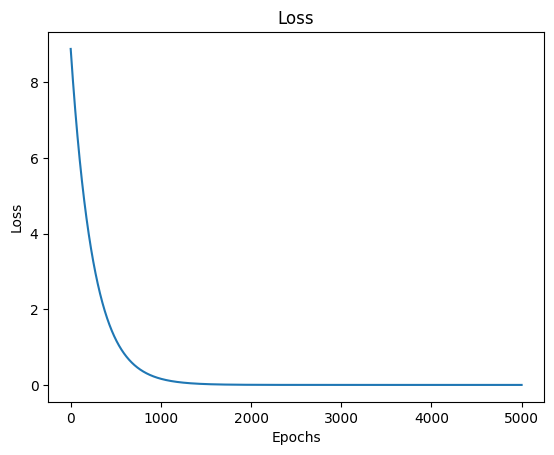

In [102]:
import numpy as np 
import matplotlib.pyplot as plt

def loss(W):
    return (W - 3)**2

def gradient(W):
    return 2*(W - 3)

weights = []

losses = []

w = np.random.randn()

learning_rate = 0.001

for i in range(5000):
    grad = gradient(w)

    w = w - learning_rate * grad

    weights.append(w)
    losses.append(loss(w))

plt.plot(losses)
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [113]:
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# ============================
# Activation Functions
# ============================

def sigmoid(x):
    """Sigmoid activation"""
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    """Derivative of sigmoid"""
    return x * (1 - x)


# ============================
# Neural Network Class
# ============================

class NeuralNetwork:
    
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.1):
        
        # Learning rate
        self.lr = learning_rate
        
        # Initialize weights randomly
        self.W1 = np.random.randn(hidden_size, input_size)
        self.b1 = np.zeros((hidden_size, 1))
        
        self.W2 = np.random.randn(output_size, hidden_size)
        self.b2 = np.zeros((output_size, 1))


    def forward(self, X):
        """
        Forward propagation
        X shape: (input_size, number_of_samples)
        """
        
        # Hidden layer
        self.z1 = np.dot(self.W1, X) + self.b1
        self.a1 = sigmoid(self.z1)
        
        # Output layer
        self.z2 = np.dot(self.W2, self.a1) + self.b2
        self.a2 = sigmoid(self.z2)
        
        return self.a2


    def backward(self, X, Y):
        """
        Backpropagation
        """
        
        m = X.shape[1]  # number of samples
        
        # Output layer gradient
        dz2 = self.a2 - Y
        dW2 = (1/m) * np.dot(dz2, self.a1.T)
        db2 = (1/m) * np.sum(dz2, axis=1, keepdims=True)
        
        # Hidden layer gradient
        dz1 = np.dot(self.W2.T, dz2) * sigmoid_derivative(self.a1)
        dW1 = (1/m) * np.dot(dz1, X.T)
        db1 = (1/m) * np.sum(dz1, axis=1, keepdims=True)
        
        # Gradient descent update
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1


    def train(self, X, Y, epochs=10000):
        """
        Training loop
        """
        
        for epoch in range(epochs):
            
            # Forward pass
            output = self.forward(X)
            
            # Backward pass
            self.backward(X, Y)
            
            # Compute loss
            loss = np.mean((Y - output)**2)
            
            if epoch % 1000 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")


    def predict(self, X):
        """
        Make predictions
        """
        output = self.forward(X)
        return (output > 0.5).astype(int)

In [118]:
X = np.array(
    [
        [0,0,1,1],
        [0,1,0,1]
    ]
)
    
Y = np.array([[0,1,1,0]])

## train

nn = NeuralNetwork(2,8,1,learning_rate = 2)

nn.train(X,Y,epochs = 10000)

Epoch 0, Loss: 0.3217
Epoch 1000, Loss: 0.0000
Epoch 2000, Loss: 0.0000
Epoch 3000, Loss: 0.0000
Epoch 4000, Loss: 0.0000
Epoch 5000, Loss: 0.0000
Epoch 6000, Loss: 0.0000
Epoch 7000, Loss: 0.0000
Epoch 8000, Loss: 0.0000
Epoch 9000, Loss: 0.0000


In [116]:
## Test prediction

predictions =  nn.predict(X)

print( "Predicted label" ,predictions)

print("True label:", Y)

Predicted label [[0 1 1 0]]
True label: [[0 1 1 0]]


## 3️⃣ Build Deep Neural Network From Scratch (NumPy)
- 
- This version supports multiple hidden layers.

In [124]:
import numpy as np

np.random.seed(42)

# Activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)


class DeepNeuralNetwork:
    
    def __init__(self, layer_sizes, learning_rate=0.1):
        """
        layer_sizes example: [2, 6, 4, 3, 1]
        """
        
        self.layer_sizes = layer_sizes
        self.lr = learning_rate
        
        self.weights = []
        self.biases = []
        
        # Initialize weights and biases
        for i in range(len(layer_sizes) - 1):
            
            W = np.random.randn(layer_sizes[i+1], layer_sizes[i])
            b = np.zeros((layer_sizes[i+1], 1))
            
            self.weights.append(W)
            self.biases.append(b)


    def forward(self, X):
        
        self.activations = [X]
        
        A = X
        
        # Loop through all layers
        for W, b in zip(self.weights, self.biases):
            
            Z = np.dot(W, A) + b
            A = sigmoid(Z)
            
            self.activations.append(A)
        
        return A


    def backward(self, Y):
        
        m = Y.shape[1]
        
        dA = self.activations[-1] - Y
        
        for i in reversed(range(len(self.weights))):
            
            A = self.activations[i+1]
            A_prev = self.activations[i]
            
            dZ = dA * sigmoid_derivative(A)
            
            dW = (1/m) * np.dot(dZ, A_prev.T)
            db = (1/m) * np.sum(dZ, axis=1, keepdims=True)
            
            if i > 0:
                dA = np.dot(self.weights[i].T, dZ)
            
            # Update weights
            self.weights[i] -= self.lr * dW
            self.biases[i] -= self.lr * db


    def train(self, X, Y, epochs=10000):
        
        for epoch in range(epochs):
            
            output = self.forward(X)
            
            self.backward(Y)
            
            loss = np.mean((Y - output)**2)
            
            if epoch % 1000 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")


    def predict(self, X):
        
        output = self.forward(X)
        
        return (output > 0.5).astype(int)



In [125]:
# XOR dataset
X = np.array([
    [0, 0, 1, 1],
    [0, 1, 0, 1]
])

Y = np.array([[0, 1, 1, 0]])

dnn = DeepNeuralNetwork([2, 6, 4, 3, 1], learning_rate=0.5)

dnn.train(X,Y,10000)

predictions = dnn.predict(X)

print("Predictions:", predictions)
print("True labels:", Y)

Epoch 0, Loss: 0.2657
Epoch 1000, Loss: 0.2426
Epoch 2000, Loss: 0.1905
Epoch 3000, Loss: 0.0128
Epoch 4000, Loss: 0.0024
Epoch 5000, Loss: 0.0012
Epoch 6000, Loss: 0.0008
Epoch 7000, Loss: 0.0005
Epoch 8000, Loss: 0.0004
Epoch 9000, Loss: 0.0003
Predictions: [[0 1 1 0]]
True labels: [[0 1 1 0]]


- 2️⃣ Types of Regularization
- 
- We will learn and implement:
- 
- L2 Regularization (Weight decay)
- 
- L1 Regularization
- 
- Dropout (VERY important)

In [ ]:
import numpy as np 

np.random.seed(42)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

class NeuralNetwork2:

    def __init__(self, layer_sizes , learning_rate = 0.1,lembda_reg=0.01):
        self.lr = learning_rate 

        self.layers_sizes = layer_sizes
        self.lambda_reg = lambda_reg

        self.weights = []
        self.biases = []

        for i in range(len(layer_sizes) - 1):
            w = np.random.randn(layer_sizes[i+1], layer_sizes[i])

            b = np.zeros((layer_sizes[i+1], 1))

            self.weights.append(w)
            self.biases.append(b)
    
    def forward(self,X):
        self.activations = [X]

        A = X

        for W,b in zip(self.weights,self.biases):

            Z = np.dot(W,A) + b


            A = sigmoid(Z)

            self.activations.append(A)
        
        return A
    
    def backword(self,Y):

        m = Y.shape[1]

        dA = ae;f.activation[-1] - Y

        for i in reversed(range(len(self.weights))):

            A = self.activations[i+1]

            A_prev = self.activations[i]

            dZ = dA * sigmoid_derivative(A)

            dW = (1/m) * np.dot(dZ, A_prev.T) + (self.lambda_reg/m) + self.weights[i]

            db = (1/m) * np.sum(dZ, axis=1, keepdims=True)

            if i > 0:
                dA = np.dot(self.weights[i].T,dZ)


            self.weights[i] -= self.lr * dW

            self.biases[i] -= self.lr * db



    def train(self,X,Y,epochs=5000):

        for epoch in range(epochs):

            output = self.forward(X)

            self.backward(Y)

            loss = np.mean((output - Y)**2)

            if epoch % 1000 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")

    

In [127]:
def dropout(A, rate):

    mask = (np.random.rand(*A.shape) > rate)

    A = A * mask

    A = A/(1-rate)

    return A, mask 